Dataset Overview:
Number of patients: 10
Number of features: 12
Class distribution: {1: 7, 0: 3}

Accuracy: 0.67

Classification Report:
                  precision    recall  f1-score   support

Survival Class 0       0.00      0.00      0.00         1
Survival Class 1       0.67      1.00      0.80         2

        accuracy                           0.67         3
       macro avg       0.33      0.50      0.40         3
    weighted avg       0.44      0.67      0.53         3


Confusion Matrix:
[[0 1]
 [0 2]]

Cross-validation scores: [1.  1.  0.5 0.5 0. ]
Mean CV accuracy: 0.60

Feature Importance:
               Feature  Importance
11     Survival_Months         1.0
0                  Age         0.0
1               Gender         0.0
2        Tumor_Size_mm         0.0
3                Stage         0.0
4           Metastasis         0.0
5        Gene_Mutation         0.0
6      Smoking_History         0.0
7       Family_History         0.0
8   Radiation_Exposure         0.0
9

C:\Users\KIIT\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\KIIT\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\KIIT\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C

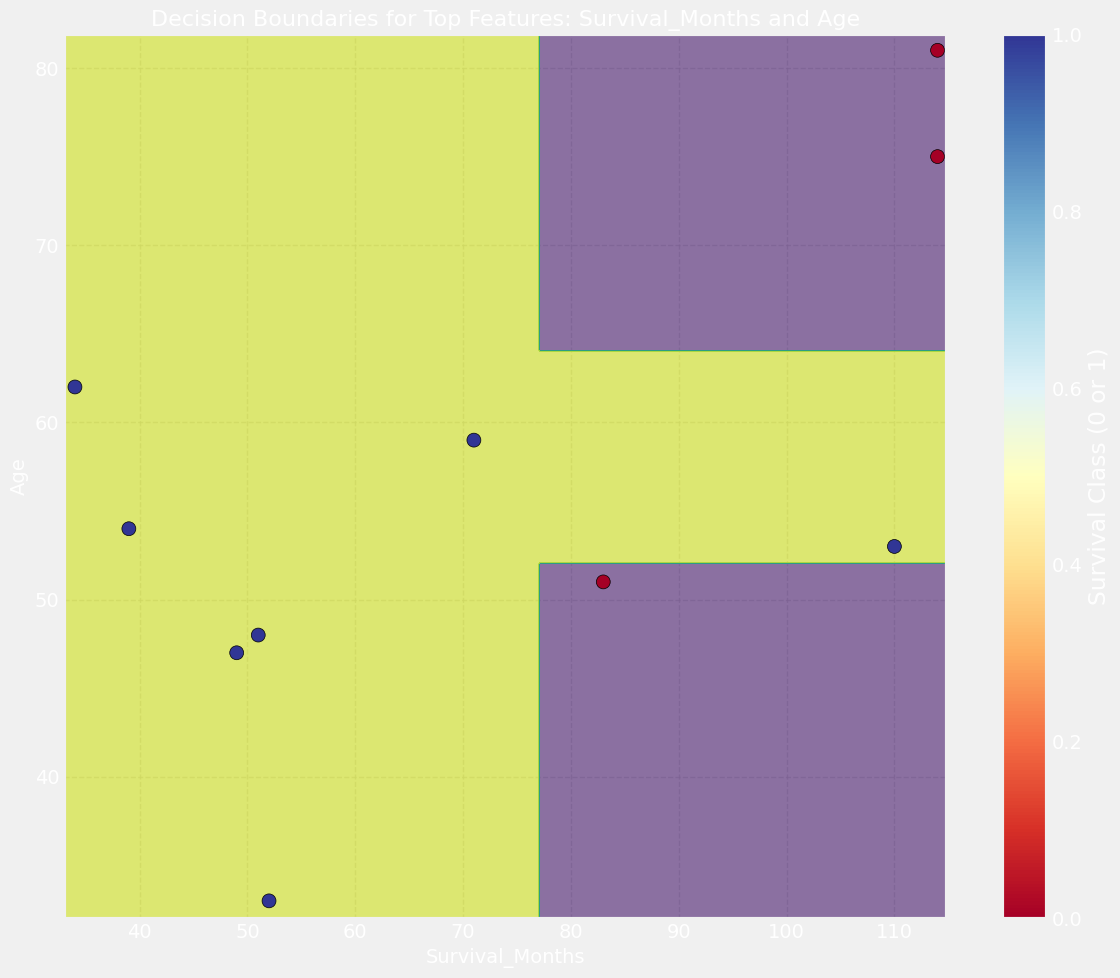

In [3]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn import tree
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set a vibrant color palette
sns.set_palette("viridis")
plt.style.use('fivethirtyeight')

# Load the data
data = """Patient_ID,Age,Gender,Tumor_Size_mm,Stage,Metastasis,Gene_Mutation,Smoking_History,Family_History,Radiation_Exposure,Imaging_Result,Blood_Marker_Level,Survival_Months,Label
PID0003,47,0,10.2,0,0,2,2,0,0,1,19.48,49,1
PID0006,48,0,23.7,0,0,0,1,1,0,1,13.28,51,1
PID0009,54,0,30.1,1,0,3,2,0,1,0,17.48,39,1
PID0011,59,1,24.8,0,1,4,1,1,1,0,13.37,71,1
PID0019,81,1,96.1,0,1,3,2,1,1,0,2.84,114,0
PID0020,51,1,42.5,2,0,1,2,0,0,1,3.05,83,0
PID0023,53,1,74.5,1,0,2,2,1,1,1,13.91,110,1
PID0026,75,1,31.5,0,0,1,2,1,1,0,15.71,114,0
PID0028,33,0,86.0,1,1,0,1,0,0,0,13.37,52,1
PID0029,62,0,96.7,2,0,4,2,0,1,1,2.75,34,1"""

# Convert to DataFrame
from io import StringIO
df = pd.read_csv(StringIO(data))

# Display basic info about the data
print("Dataset Overview:")
print(f"Number of patients: {len(df)}")
print(f"Number of features: {df.shape[1] - 2}")  # Excluding Patient_ID and Label
print(f"Class distribution: {df['Label'].value_counts().to_dict()}")

# Preprocessing
# Drop the Patient_ID column which is causing the error
df_analysis = df.drop(['Patient_ID'], axis=1)

# Prepare features and target
X = df_analysis.drop(['Label'], axis=1)
y = df_analysis['Label']

# Split the data (small dataset, so we'll use cross-validation later)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train the decision tree
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]  # Probability for class 1

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.2f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Survival Class 0', 'Survival Class 1']))

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Cross-validation to get a better estimate of model performance
cv_scores = cross_val_score(clf, X, y, cv=5)
print(f"\nCross-validation scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.2f}")

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': clf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)

# Create directory for saving images if it doesn't exist
if not os.path.exists('patient_decision_tree_plots'):
    os.makedirs('patient_decision_tree_plots')

# 1. Decision Tree Visualization
plt.figure(figsize=(16, 12))
tree.plot_tree(clf, feature_names=X.columns, class_names=['Class 0', 'Class 1'], 
               filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree for Patient Survival Prediction", fontsize=18)
plt.tight_layout()
plt.savefig('patient_decision_tree_plots/decision_tree.jpg', dpi=300, bbox_inches='tight')
plt.close()

# 2. Feature Importance
plt.figure(figsize=(12, 8))
ax = sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='plasma')
plt.title("Feature Importance in Survival Prediction", fontsize=18)
plt.xlabel('Importance Score', fontsize=14)
plt.ylabel('Feature', fontsize=14)

# Add value labels to the bars
for i, v in enumerate(feature_importance['Importance']):
    ax.text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=10)
    
plt.tight_layout()
plt.savefig('patient_decision_tree_plots/feature_importance.jpg', dpi=300, bbox_inches='tight')
plt.close()

# 3. Confusion Matrix Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='YlGnBu', 
            xticklabels=['Class 0', 'Class 1'], 
            yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.title('Confusion Matrix for Survival Prediction', fontsize=18)
plt.tight_layout()
plt.savefig('patient_decision_tree_plots/confusion_matrix.jpg', dpi=300, bbox_inches='tight')
plt.close()

# 4. Cross-validation scores
plt.figure(figsize=(12, 8))
ax = sns.barplot(x=range(1, len(cv_scores)+1), y=cv_scores, palette='coolwarm')
plt.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean: {cv_scores.mean():.2f}')
plt.xlabel('Fold', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.title(f'Cross-validation Scores (Mean: {cv_scores.mean():.2f})', fontsize=18)
plt.legend(fontsize=12)

# Add values on top of bars
for i, v in enumerate(cv_scores):
    ax.text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=12)

plt.tight_layout()
plt.savefig('patient_decision_tree_plots/cross_validation_scores.jpg', dpi=300, bbox_inches='tight')
plt.close()

# 5. ROC Curve
plt.figure(figsize=(10, 8))
# Calculate ROC curve
if len(np.unique(y_test)) > 1:  # Check if we have both classes in test set
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=14)
    plt.ylabel('True Positive Rate', fontsize=14)
    plt.title('Receiver Operating Characteristic (ROC)', fontsize=18)
    plt.legend(loc="lower right", fontsize=12)
else:
    plt.text(0.5, 0.5, "Insufficient class diversity in test set for ROC curve", 
             horizontalalignment='center', fontsize=14)
    
plt.tight_layout()
plt.savefig('patient_decision_tree_plots/roc_curve.jpg', dpi=300, bbox_inches='tight')
plt.close()

# 6. Combined visualization
plt.figure(figsize=(20, 16))

# 6.1 Decision Tree (simplified for combined view)
plt.subplot(2, 2, 1)
tree.plot_tree(clf, feature_names=X.columns, class_names=['Class 0', 'Class 1'], 
               filled=True, rounded=True, fontsize=6, max_depth=3)
plt.title("Decision Tree (Truncated)", fontsize=16)

# 6.2 Feature Importance
plt.subplot(2, 2, 2)
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10), palette='plasma')
plt.title("Top 10 Feature Importance", fontsize=16)
plt.xlabel('Importance Score')

# 6.3 Confusion Matrix Heatmap
plt.subplot(2, 2, 3)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='YlGnBu', 
            xticklabels=['Class 0', 'Class 1'], 
            yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix', fontsize=16)

# 6.4 Cross-validation scores
plt.subplot(2, 2, 4)
bars = sns.barplot(x=range(1, len(cv_scores)+1), y=cv_scores, palette='coolwarm')
plt.axhline(cv_scores.mean(), color='red', linestyle='--')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title(f'Cross-validation Scores (Mean: {cv_scores.mean():.2f})', fontsize=16)

plt.tight_layout()
plt.savefig('patient_decision_tree_plots/combined_visualization.jpg', dpi=300, bbox_inches='tight')
plt.close()

# 7. Class distribution
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='Label', data=df_analysis, palette=['#ff9999', '#66b3ff'])
plt.title('Class Distribution in Dataset', fontsize=16)
plt.xlabel('Survival Class', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks([0, 1], ['Class 0', 'Class 1'])

# Add count labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.savefig('patient_decision_tree_plots/class_distribution.jpg', dpi=300, bbox_inches='tight')
plt.close()

# 8. Feature correlation matrix with numeric features only
# Convert df_analysis to numeric columns only
numeric_df = df_analysis.select_dtypes(include=[np.number])
plt.figure(figsize=(14, 10))
correlation = numeric_df.corr()
mask = np.triu(np.ones_like(correlation, dtype=bool))
sns.heatmap(correlation, mask=mask, cmap='coolwarm', annot=True, fmt='.2f', 
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix', fontsize=18)
plt.tight_layout()
plt.savefig('patient_decision_tree_plots/correlation_matrix.jpg', dpi=300, bbox_inches='tight')
plt.close()

# 9. Feature distribution by class
numerical_features = ['Age', 'Tumor_Size_mm', 'Blood_Marker_Level', 'Survival_Months']
plt.figure(figsize=(16, 12))

for i, feature in enumerate(numerical_features):
    plt.subplot(2, 2, i+1)
    sns.boxplot(x='Label', y=feature, data=df_analysis, palette=['#ff9999', '#66b3ff'])
    plt.title(f'{feature} by Survival Class', fontsize=14)
    plt.xlabel('Survival Class', fontsize=12)
    plt.ylabel(feature, fontsize=12)
    plt.xticks([0, 1], ['Class 0', 'Class 1'])

plt.tight_layout()
plt.savefig('patient_decision_tree_plots/feature_distribution_by_class.jpg', dpi=300, bbox_inches='tight')
plt.close()

# 10. Decision boundaries for top two features (if possible)
if len(feature_importance) >= 2:
    plt.figure(figsize=(12, 10))
    
    # Get the two most important features
    top_features = feature_importance['Feature'].iloc[:2].tolist()
    
    # Create a meshgrid to plot decision boundaries
    x_min, x_max = X[top_features[0]].min() - 1, X[top_features[0]].max() + 1
    y_min, y_max = X[top_features[1]].min() - 1, X[top_features[1]].max() + 1
    
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    
    # Train a new classifier with only these two features
    clf_2d = DecisionTreeClassifier(random_state=42)
    clf_2d.fit(X[top_features], y)
    
    # Predict on the meshgrid
    Z = clf_2d.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot the decision boundary with a more vibrant colormap
    plt.contourf(xx, yy, Z, alpha=0.6, cmap='viridis')
    
    # Plot the data points with distinct colors
    scatter = plt.scatter(X[top_features[0]], X[top_features[1]], 
                          c=y, cmap='RdYlBu', edgecolor='k', s=100)
    
    plt.xlabel(top_features[0], fontsize=14)
    plt.ylabel(top_features[1], fontsize=14)
    plt.title(f'Decision Boundaries for Top Features: {top_features[0]} and {top_features[1]}', fontsize=16)
    plt.colorbar(scatter, label='Survival Class (0 or 1)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('patient_decision_tree_plots/decision_boundaries.jpg', dpi=300, bbox_inches='tight')
    plt.close